In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'output/sis/RR/z=6/N=10000c'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    c_min = params['cMin'].values[0]
    c_max = params['cMax'].values[0]
    dc = params['dc'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    lambda_list = params['lambdaList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    lambda_list = lambda_list.split(":")
    lambda_list = [float(lam) for lam in lambda_list]

    c_values = _build_c_values(c_min, c_max, dc)

    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, lambda_list, c_values


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def _build_c_values(c_min, c_max, dc) -> np.ndarray:
    # Replicate Java's inclusive arange: ((end-start)/step) + 1
    count = int(round((c_max - c_min) / dc)) + 1
    c = c_min + dc * np.arange(count)
    # Reduce tiny FP noise
    return np.round(c, 10)


def load_batch(output_dir: str, batch_idx: int, ) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, lambda_values = _read_params(params_path)

    C, L = len(c_list), len(lambda_values)
    expected = C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((C, L, itr), dtype=object)
    infected = np.empty((C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for c in range(C):
        for l in range(L):
            for i in range(itr):
                time[c, l, i] = np.array([], dtype=float)
                infected[c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            cIdx = flat_idx // (L * itr)
            rem = flat_idx % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[cIdx, lIdx, itIdx] = tarr
            infected[cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    return time, infected

def load(path: str = output_path, max_file_num: int = 1e5) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, lambda_list, c_values = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(lambda_list), len(c_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        times, infected_num = load_batch(path, batch_idx)
        times_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "lambda_list": lambda_list,
        "c_values": c_values,
    }

    return times_all, infected_num_all, axes

In [3]:
import numpy as np

# =========================
# 0) 標準：平均場 (MF)
# =========================

def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    """
    y(Θ) = (1/<k>) Σ_k k P(k) * [ λ k Θ / ( γ/(1 + c k Θ) + λ k Θ ) ] - Θ
    root y(Θ)=0 を解いて Θ* を得る。
    """
    k_ave = float(np.sum(deg_list * pk))
    if k_ave == 0.0:
        return -Theta
    y = 0.0
    for k, p in zip(deg_list, pk):
        k = int(k)
        if k == 0 or p == 0:
            continue
        gamma_bar = gamma / (1.0 + c * k * Theta)
        denom = gamma_bar + lamb * k * Theta
        if denom <= 0.0:
            continue
        ik = (lamb * k * Theta) / denom
        y += k * p * ik
    return float(y / k_ave - Theta)


def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    """
    y'(Θ) = (1/<k>) Σ_k k P(k) * d/dΘ[ ... ] - 1
    d/dΘ i_k = [λ γ k (1 + 2 c k Θ)] / [γ + λ k Θ (1 + c k Θ)]^2
    """
    k_ave = float(np.sum(deg_list * pk))
    if k_ave == 0.0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        k = int(k)
        if k == 0 or p == 0:
            continue
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)
        if B == 0.0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    return float(dy / k_ave - 1.0)


def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9,
                  tolerance=1e-12, max_iter=100, c=0.0):
    """
    y_SIS(Θ)=0 を Newton で解く（端のクリップ＋減衰付き）
    """
    Theta = float(np.clip(Theta_initial, 0.0, 1.0))
    for _ in range(max_iter):
        yv = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        if abs(yv) < tolerance:
            return float(np.clip(Theta, 0.0, 1.0))
        dyv = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)
        if not np.isfinite(dyv) or abs(dyv) < 1e-14:
            Theta = float(np.clip(Theta - 0.5*np.sign(yv)*min(abs(yv),1.0), 0.0, 1.0))
            continue
        Theta_new = Theta - yv/dyv
        if not (0.0 <= Theta_new <= 1.0):
            Theta_new = float(np.clip(Theta_new, 0.0, 1.0))
            Theta = 0.5*Theta + 0.5*Theta_new
        else:
            Theta = Theta_new
        if abs(yv) < tolerance:
            break
    return float(np.clip(Theta, 0.0, 1.0))


def theta_to_I_standard(deg_list, pk, lamb, gamma, Theta, c=0.0):
    """
    I = Σ_k P(k) * i_k(Θ)  （※「I≠Θ」バグ修正済）
    """
    I = 0.0
    for k, p in zip(deg_list, pk):
        k = int(k)
        if k == 0 or p == 0:
            continue
        gamma_bar = gamma / (1.0 + c * k * Theta)
        denom = gamma_bar + lamb * k * Theta
        if denom <= 0.0:
            continue
        ik = (lamb * k * Theta) / denom
        I += p * ik
    return float(I)


def theta_symbolic_RR_numeric(lamb: float, K: int, gamma: float, c: float) -> float:
    """
    正則(RR)の閉形式： (cK)Θ^2 + (1-cK)Θ + (γ/(λK) - 1) = 0（c>0）、
    c=0 は Θ=max(0, 1 - γ/(λK)).
    """
    if lamb <= 0:
        return 0.0
    if c == 0.0:
        return float(np.clip(1.0 - gamma/(lamb*K), 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma/(lamb*K) - 1.0
    D = b*b - 4.0*a*c0
    if D < 0.0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0*a)
    return float(np.clip(theta, 0.0, 1.0))


# ==========================================
# 1) Jensen 補正（I 条件付き：サイズバイアス）
# ==========================================

def _Ek_I_conditional(k: int, Theta: float, c: float, eps: float = 1e-12) -> float:
    """
    E_I[1/(1+c m)] with size-biased weights w_m ∝ m * Bin(k,Θ).
    Θ→0 では ~1/(1+c)。
    """
    if c == 0.0:
        return 1.0
    theta = float(np.clip(Theta, 0.0, 1.0))
    if theta < eps:
        return 1.0 / (1.0 + c)

    p = 1.0 - theta
    q = theta
    # P(0)
    Pm = p ** k

    wsum = 0.0
    acc = 0.0
    for m in range(1, k + 1):
        if m == 1:
            Pm = Pm * k * (q / p)
        else:
            Pm = Pm * (k - (m - 1)) / m * (q / p)
        w = m * Pm
        wsum += w
        acc += w * (1.0 / (1.0 + c * m))
    if wsum == 0.0:
        return 1.0 / (1.0 + c)
    return acc / wsum


def y_SIS_jensen_Icond(deg_list, pk, lamb, gamma, Theta, c=0.0):
    """
    y(Θ) = (1/<k>) Σ_k k P(k) * [ λ k Θ / ( γ E_I[1/(1+c m)] + λ k Θ ) ] - Θ
    """
    k_ave = float(np.sum(deg_list * pk))
    if k_ave == 0.0:
        return -Theta
    y = 0.0
    for k, p in zip(deg_list, pk):
        k = int(k)
        if k == 0 or p == 0:
            continue
        EkI = _Ek_I_conditional(k, float(Theta), float(c))
        denom = gamma * EkI + lamb * k * Theta
        if denom <= 0.0:
            continue
        ik = (lamb * k * Theta) / denom
        y += k * p * ik
    return float(y / k_ave - Theta)


def solve_theta_jensen_Icond_bisect(deg_list, pk, lamb, gamma, c,
                                    eps=1e-12, tol=1e-12, max_iter=200):
    """
    y_SIS_jensen_Icond(Θ)=0 を二分法で解く。
    y(ε)>0 のときだけ正の根があると判断し、なければ Θ=0 を返す。
    """
    y0 = y_SIS_jensen_Icond(deg_list, pk, lamb, gamma, eps, c)
    if y0 <= 0.0:
        return 0.0
    lo, hi = eps, 1.0 - eps
    flo = y0
    fhi = y_SIS_jensen_Icond(deg_list, pk, lamb, gamma, hi, c)
    if fhi >= 0.0:
        for a in np.linspace(0.99, 0.5, 6):
            hitry = a * hi
            fhi = y_SIS_jensen_Icond(deg_list, pk, lamb, gamma, hitry, c)
            if fhi < 0.0:
                hi = hitry
                break
        else:
            return 0.0
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fm = y_SIS_jensen_Icond(deg_list, pk, lamb, gamma, mid, c)
        if fm > 0.0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return float(np.clip(0.5*(lo+hi), 0.0, 1.0))


def theta_to_I_jensen_Icond(deg_list, pk, lamb, gamma, Theta, c=0.0):
    """
    Jensen（I 条件付き）で I を評価： I = Σ P(k) i_k(Θ),
    i_k(Θ) = [λ k Θ] / [γ E_I[1/(1+c m)] + λ k Θ]
    """
    I = 0.0
    for k, p in zip(deg_list, pk):
        k = int(k)
        if k == 0 or p == 0:
            continue
        EkI = _Ek_I_conditional(k, float(Theta), float(c))
        denom = gamma * EkI + lamb * k * Theta
        if denom <= 0.0:
            continue
        ik = (lamb * k * Theta) / denom
        I += p * ik
    return float(I)


# =========================
# 2) 便利ラッパ（任意）
# =========================

def sweep_theta_jensen_continuation_Icond(deg_list, pk, lambda_list, c_grid, gamma):
    """
    c を小→大に掃きながら Jensen(I条件) の Θ を追跡（単調非減少を強制）。
    """
    theta_all = np.zeros((len(lambda_list), len(c_grid)))
    for lidx, lamb in enumerate(lambda_list):
        theta_prev = 0.0
        for i, c in enumerate(c_grid):
            theta = solve_theta_jensen_Icond_bisect(deg_list, pk, lamb, gamma, c)
            if theta < theta_prev:  # 単調制約
                theta = theta_prev
            theta_all[lidx, i] = theta
            theta_prev = theta
    return theta_all


In [4]:
times_all, infected_num_all, axes = load(max_file_num=3)
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
lambda_list = axes["lambda_list"]
c_values = axes["c_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found

Lets load 3 files!
 --> Loading 0th file...
 --> Loading 1th file...
 --> Loading 2th file...


In [5]:
print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

print("")
print("==== meta data ====")
for key, value in meta.items():
    print(f"{key}: {value}")

==== shape ====
(2, 151, 30)
(2, 151, 30)

==== params ====
network_type: RR
N: 10000
k_ave: 6
gamma: 1.0
rho0: 1.0
tmax: 400.0
seed: 0.0
total_itr: 30

==== meta data ====
start_time: 2025-09-05 15:37:20
end_time: 2025-09-05 16:02:33
duration_seconds: 1512.804
network_type: RR
runs_per_batch: 3020
total_runs: 96640
seed_base: 0
os_name: Mac OS X
os_version: 15.6
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 16
total_memory_mb: 744
max_memory_mb: 12288


In [6]:
c_idx_list = [0, 20, 40, 80, 150]

In [7]:
threshold = -1

last_I = np.zeros((len(lambda_list), len(c_values), total_itr))
valid_last_I = np.zeros((len(lambda_list), len(c_values)))
valid_num = np.zeros((len(lambda_list), len(c_values)))
for lamb_idx, lamb in enumerate(lambda_list):
    for c_idx, c in enumerate(c_values):
        valid = []
        non_valid = []
        for itr_idx in range(len(infected_num_all[lamb_idx, c_idx])):
            last_I[lamb_idx, c_idx, itr_idx] = infected_num_all[lamb_idx, c_idx, itr_idx][-1]
            if last_I[lamb_idx, c_idx, itr_idx] > threshold:
                valid.append(last_I[lamb_idx, c_idx, itr_idx])
                valid_num[lamb_idx, c_idx] += 1
            else:
                non_valid.append(last_I[lamb_idx, c_idx, itr_idx])
        if len(valid) > 0:
            valid_last_I[lamb_idx, c_idx] = np.mean(valid)
        else:
            valid_last_I[lamb_idx, c_idx] = np.mean(non_valid)


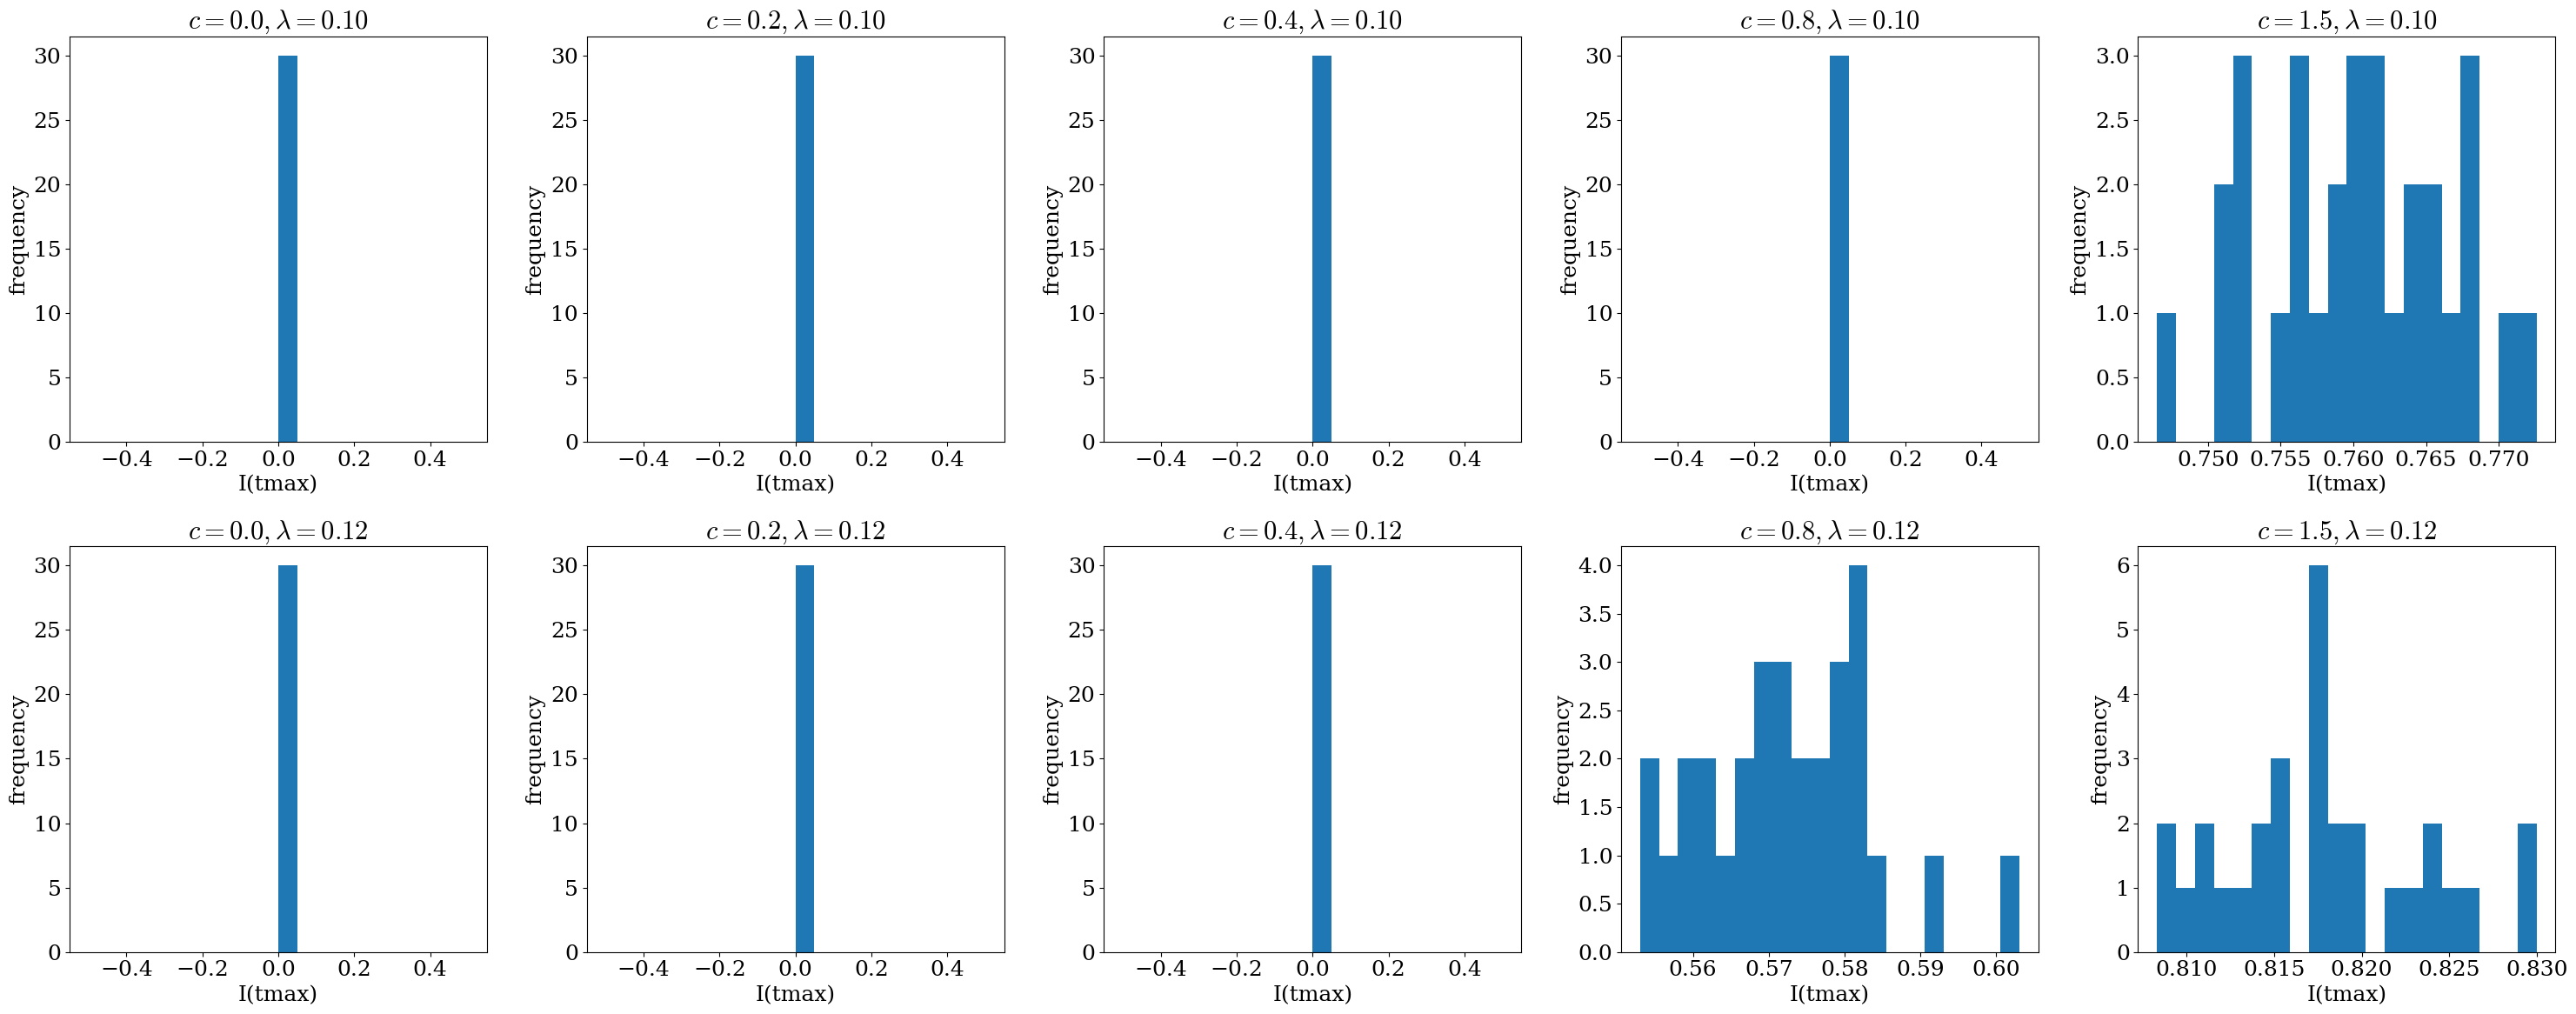

In [8]:
fig, axes = plt.subplots(len(lambda_list), len(c_idx_list), figsize=(6 * len(c_idx_list), 6 * len(lambda_list)))

for l_idx, lamb in enumerate(lambda_list):
    for cidx, c_idx in enumerate(c_idx_list):
        c = c_values[c_idx]
        axes[l_idx, cidx].hist(last_I[l_idx, c_idx, :]/N, bins=20)
        axes[l_idx, cidx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes[l_idx, cidx].set_xlabel("I(tmax)")
        axes[l_idx, cidx].set_ylabel("frequency")

fig.tight_layout()

plt.show()

In [9]:
c_values_for_theory = np.linspace(np.min(c_values), np.max(c_values), 1000)
I_all_theory = np.zeros((len(lambda_list), len(c_values_for_theory)))
I_all_jensen = np.zeros((len(lambda_list), len(c_values_for_theory)))

kappa = 2.5

for lidx, lamb in enumerate(lambda_list):
    theta_results = []
    theta_results_jensen = []
    # 各lambdaについてニュートン法でThetaを解く

    if network_type == "RR":
        deg_list = [k_ave]
        pk = np.array([1.0])

    elif network_type == "ER":
        deg_list = np.arange(0, int(k_ave * 3) + 10)
        pk = scipy.stats.poisson.pmf(deg_list, k_ave)

    elif network_type == "SF":
        deg_list = np.arange(1, 1000)
        C = (2 - kappa) * k_ave
        pk = C * deg_list ** (- kappa)

    else:
        raise ValueError(f"Invalid network type: {network_type}")

    for c_idx, c in enumerate(c_values_for_theory):
            solution = theta_symbolic_RR_numeric(lamb, k_ave, gamma, c) if network_type == "RR" else newton_method(deg_list, pk, lamb, gamma, c=c)
            solution_jensen = solve_theta_jensen_Icond_bisect(deg_list, pk, lamb, gamma, c=c)

            # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
            # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
            
            # 物理的に意味のある解は Theta >= 0
            solution = float(np.clip(solution, 0.0, 1.0))
            solution_jensen = float(np.clip(solution_jensen, 0.0, 1.0))

            I_all_theory[lidx, c_idx] = theta_to_I_standard(deg_list, pk, lamb, gamma, solution, c)
            I_all_jensen[lidx, c_idx] = theta_to_I_jensen_Icond(deg_list, pk, lamb, gamma, solution_jensen, c)

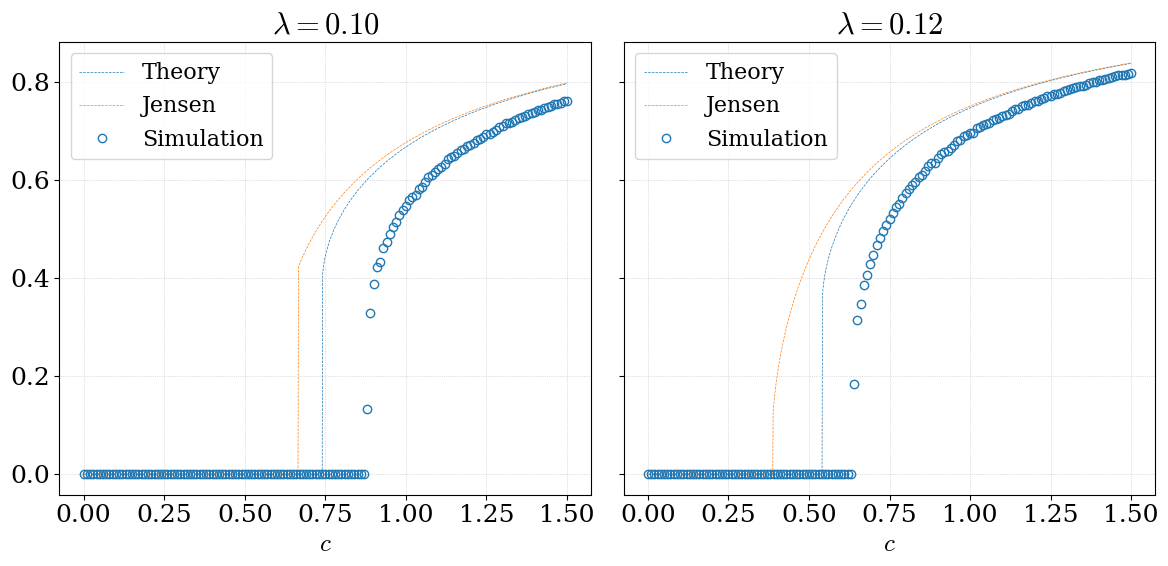

In [10]:
fig, axes = plt.subplots(1, len(lambda_list), figsize=(6 * len(lambda_list), 6), sharey=True)

for l_idx, lamb in enumerate(lambda_list):
    axes[l_idx].plot(c_values_for_theory, I_all_theory[l_idx, :], color=colors[0], label="Theory", linestyle="--", linewidth=0.5)
    axes[l_idx].plot(c_values_for_theory, I_all_jensen[l_idx, :], color=colors[1], label="Jensen", linestyle="--", linewidth=0.5)
    
    valid_mean_I = valid_last_I[l_idx, :]
    axes[l_idx].plot(c_values, valid_mean_I/N, label="Simulation", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    axes[l_idx].legend()
    axes[l_idx].grid(True, linestyle=":", alpha=0.5)
    axes[l_idx].set_title(rf"$\lambda={lamb:.2f}$")
    axes[l_idx].set_xlabel(r"$c$")

fig.tight_layout()

plt.show()

In [11]:
python_N = 1000
python_out_dir = f"../output/sis/{network_type}/z={k_ave}/N={python_N}time"

res = np.load(os.path.join(python_out_dir, "python.npz"), allow_pickle=True)
c_values_python = res["c_values"]
lamb_list_python = res["lamb_list"]
I_all_python = res["I_all"]
times_all_python = res["times_all"]

total_itr_python = times_all_python.shape[2]

print(c_values_python)
print(lamb_list_python)
print(I_all_python.shape)
print(times_all_python.shape)
print(total_itr_python)

[0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[0.1  0.12]
(2, 11, 100)
(2, 11, 100)
100


In [12]:
last_I_python = np.zeros((len(lamb_list_python), len(c_values_python), total_itr_python))
valid_last_I_python = np.zeros((len(lamb_list_python), len(c_values_python)))
valid_num_python = np.zeros((len(lamb_list_python), len(c_values_python)))
for lamb_idx, lamb in enumerate(lamb_list_python):
    for c_idx, c in enumerate(c_values_python):
        valid = []
        non_valid = []
        for itr_idx in range(total_itr_python):
            last_I_python[lamb_idx, c_idx, itr_idx] = I_all_python[lamb_idx, c_idx, itr_idx][-1]
            if last_I_python[lamb_idx, c_idx, itr_idx] > threshold:
                valid.append(last_I_python[lamb_idx, c_idx, itr_idx])
                valid_num_python[lamb_idx, c_idx] += 1
            else:
                non_valid.append(last_I_python[lamb_idx, c_idx, itr_idx])
        if len(valid) > 0:
            valid_last_I_python[lamb_idx, c_idx] = np.mean(valid)
        else:
            valid_last_I_python[lamb_idx, c_idx] = np.mean(non_valid)


NameError: name 'theta_to_I' is not defined

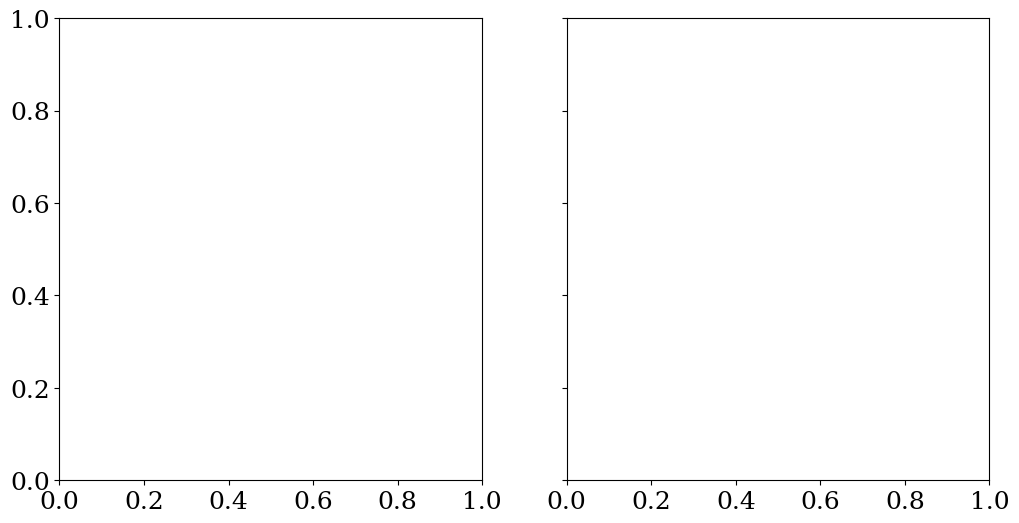

In [13]:
fig, axes = plt.subplots(1, len(lambda_list), figsize=(6 * len(lambda_list), 6), sharey=True)

for l_idx, lamb in enumerate(lambda_list):
    to_Is = np.zeros(len(c_values_for_theory))
    for c_idx, c in enumerate(c_values_for_theory):
        to_I = theta_to_I(deg_list, pk, lamb, gamma, theta_all[l_idx, c_idx], c=c)
        to_Is[c_idx] = to_I
    axes[l_idx].plot(c_values_for_theory, to_Is, color=colors[0], label="Theory", linestyle="--", linewidth=0.5)

    valid_mean_I = valid_last_I[l_idx, :]
    axes[l_idx].plot(c_values, valid_mean_I/N, label="Simulation Java", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    valid_mean_I_python = valid_last_I_python[l_idx, :]
    axes[l_idx].plot(c_values_python, valid_mean_I_python/python_N, label="Simulation Python", linestyle="", marker="^", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    axes[l_idx].legend()
    axes[l_idx].grid(True, linestyle=":", alpha=0.5)
    axes[l_idx].set_title(rf"$\lambda={lamb:.2f}$")
    axes[l_idx].set_xlabel(r"$c$")

fig.tight_layout()

plt.show()

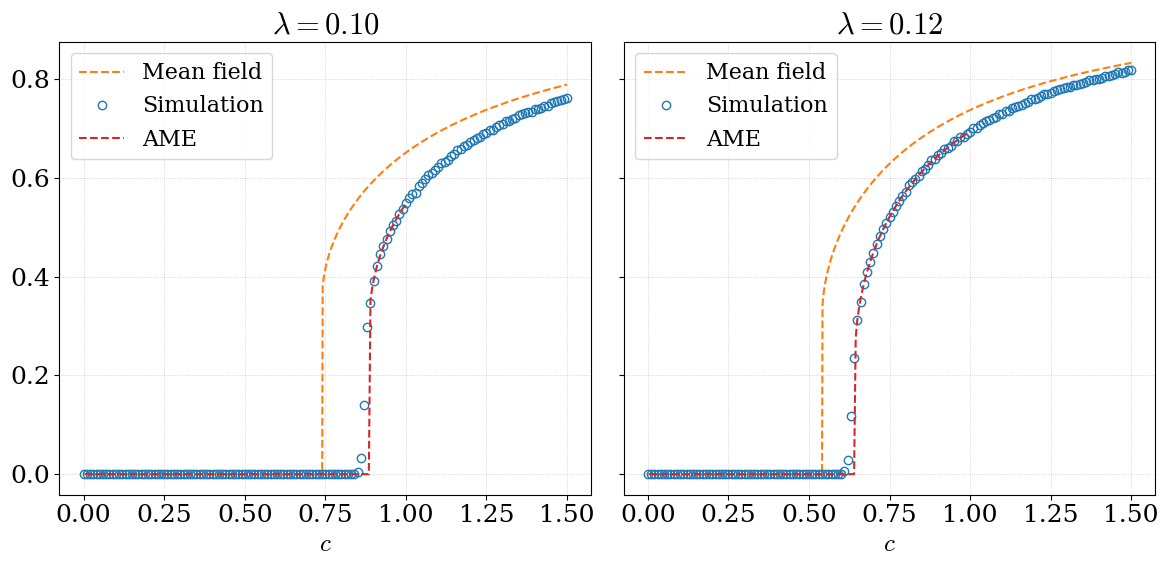

In [ ]:
arr = np.genfromtxt("../ame-0.10.dat", names=True)
c_values_ame1 = np.array(arr["beta"])
I_ame1 = np.array(arr["I"])

arr2 = np.genfromtxt("../ame-0.12.dat", names=True)
c_values_ame2 = np.array(arr2["beta"])
I_ame2 = np.array(arr2["I"])

c_values_ame = [c_values_ame1, c_values_ame2]
I_ame = [I_ame1, I_ame2]

fig, axes = plt.subplots(1, len(lambda_list), figsize=(6 * len(lambda_list), 6), sharey=True)

for l_idx, lamb in enumerate(lambda_list):
    to_Is = np.zeros(len(c_values_for_theory))
    for c_idx, c in enumerate(c_values_for_theory):
        to_I = theta_to_I(deg_list, pk, lamb, gamma, theta_all[l_idx, c_idx], c=c)
        to_Is[c_idx] = to_I
    axes[l_idx].plot(c_values_for_theory, to_Is, color=colors[1], label="Mean field", linestyle="--")

    valid_mean_I = valid_last_I[l_idx, :]
    axes[l_idx].plot(c_values, valid_mean_I/N, label="Simulation", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    valid_mean_I_python = valid_last_I_python[l_idx, :]
    # axes[l_idx].plot(c_values_python, valid_mean_I_python/python_N, label="Python", linestyle="", marker="^", markersize=6, markerfacecolor="none", markeredgecolor=colors[0])
    axes[l_idx].plot(c_values_ame[l_idx], I_ame[l_idx], label="AME", linestyle="--", color=colors[3])
    axes[l_idx].legend()
    axes[l_idx].grid(True, linestyle=":", alpha=0.5)
    axes[l_idx].set_title(rf"$\lambda={lamb:.2f}$")
    axes[l_idx].set_xlabel(r"$c$")

fig.tight_layout()

plt.show()